# Modélisation Prédictive — Scoring de Crédit Bancaire

**Auteur :** Rafika Ayari Cervera  
**Date :** Mars 2024

**Dataset :** Credit_AES.csv — 468 clients, 15 variables

---

## Objectif
Construire un modèle prédictif pour classifier les clients bancaires en **"Bon client"** ou **"Mauvais client"** afin d'automatiser et d'optimiser les décisions d'octroi de crédit.

## Plan d'analyse
1. Exploration et compréhension des données
2. Préparation et nettoyage
3. Modélisation — Régression Logistique vs Random Forest
4. Évaluation et comparaison des modèles
5. Interprétation et recommandations métier
   

In [11]:
# =============================================================
# IMPORTS — Chargement de toutes les bibliothèques nécessaires
# =============================================================

# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Gestion des warnings (pour éviter les messages inutiles)
import warnings
warnings.filterwarnings('ignore')

# Modèles de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métriques d'évaluation
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)

# Régression logistique avec affichage des coefficients statistiques
import statsmodels.api as sm

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Bibliothèques chargées avec succès")

✅ Bibliothèques chargées avec succès


## 1. Exploration et compréhension des données

In [12]:
# =============================================================
# CHARGEMENT DES DONNÉES
# =============================================================

# Lecture du fichier CSV avec séparateur ";" (format européen)
# L'identifiant client est utilisé comme index
df = pd.read_csv('../data/Credit_AES.csv', sep=';', index_col='Identifiant Client')

# Aperçu rapide du dataset
print(f"Dimensions : {df.shape[0]} clients, {df.shape[1]} variables")
print(f"\nVariable cible — répartition :")
print(df['Type de client'].value_counts())
print(f"\nTypes de données par variable :")
print(df.dtypes)

Dimensions : 468 clients, 14 variables

Variable cible — répartition :
Type de client
Bon client        237
Mauvais client    231
Name: count, dtype: int64

Types de données par variable :
Type de client                  str
Age du client                   str
Situation familiale             str
Ancienneté                      str
Domiciliation du salaire        str
Domiciliation de l'épargne      str
Profession                      str
Moyenne encours                 str
Moyenne des mouvements          str
Cumul des débits                str
Autorisation de découvert       str
Interdiction de chéquier        str
Score 1                       int64
Score 2                       int64
dtype: object


In [3]:
# Aperçu des données
display(df.head())
display(df.describe())

,Type de client,Age du client,Situation familiale,Ancienneté,Domiciliation du salaire,Domiciliation de l'épargne,Profession,Moyenne encours,Moyenne des mouvements,Cumul des débits,Autorisation de découvert,Interdiction de chéquier,Score 1,Score 2
Identifiant Client,,,,,,,,,,,,,,
5,Bon client,plus de 50 ans,célibataire,anc. plus 12 ans,Oui domicilié,pas d'épargne,employé,de 2 à 5 K encours,plus de 50K mouvt,de 40 à 100 débits,découvert interdit,chéquier autorisé,765,700
11,Bon client,moins de 23 ans,célibataire,anc. 1 an ou moins,Oui domicilié,pas d'épargne,employé,de 2 à 5 K encours,moins 10 K mouvt,moins de 40 débits,découvert interdit,chéquier autorisé,465,465
18,Mauvais client,de 23 à 39 ans,veuf,anc. de 6 à 12 ans,Oui domicilié,pas d'épargne,employé,de 2 à 5 K encours,plus de 50K mouvt,de 40 à 100 débits,découvert autorisé,chéquier interdit,680,555
24,Bon client,de 23 à 39 ans,divorcé,anc. de 1 à 4 ans,Oui domicilié,moins de 10K épargne,employé,plus de 5 K encours,de 30 à 50K mouvt,de 40 à 100 débits,découvert interdit,chéquier autorisé,560,640
30,Bon client,moins de 23 ans,célibataire,anc. de 6 à 12 ans,Non domicilié,pas d'épargne,employé,de 2 à 5 K encours,de 10 à 30K mouvt,moins de 40 débits,découvert interdit,chéquier autorisé,575,570


,Score 1,Score 2
count,468.000000,468.000000
mean,554.177350,513.408120
std,185.933367,169.463437
min,110.000000,50.000000
25%,403.750000,395.000000
50%,570.000000,500.000000
75%,690.000000,650.000000
max,945.000000,960.000000


In [13]:
# =============================================================
# CHARGEMENT DES DONNÉES
# =============================================================

# Lecture du fichier CSV avec séparateur ";" (format européen)
# L'identifiant client est utilisé comme index
df = pd.read_csv('../data/Credit_AES.csv', sep=';', index_col='Identifiant Client')

# Aperçu rapide du dataset
print(f"Dimensions : {df.shape[0]} clients, {df.shape[1]} variables")
print(f"\nVariable cible — répartition :")
print(df['Type de client'].value_counts())
print(f"\nTypes de données par variable :")
print(df.dtypes)

Dimensions : 468 clients, 14 variables

Variable cible — répartition :
Type de client
Bon client        237
Mauvais client    231
Name: count, dtype: int64

Types de données par variable :
Type de client                  str
Age du client                   str
Situation familiale             str
Ancienneté                      str
Domiciliation du salaire        str
Domiciliation de l'épargne      str
Profession                      str
Moyenne encours                 str
Moyenne des mouvements          str
Cumul des débits                str
Autorisation de découvert       str
Interdiction de chéquier        str
Score 1                       int64
Score 2                       int64
dtype: object


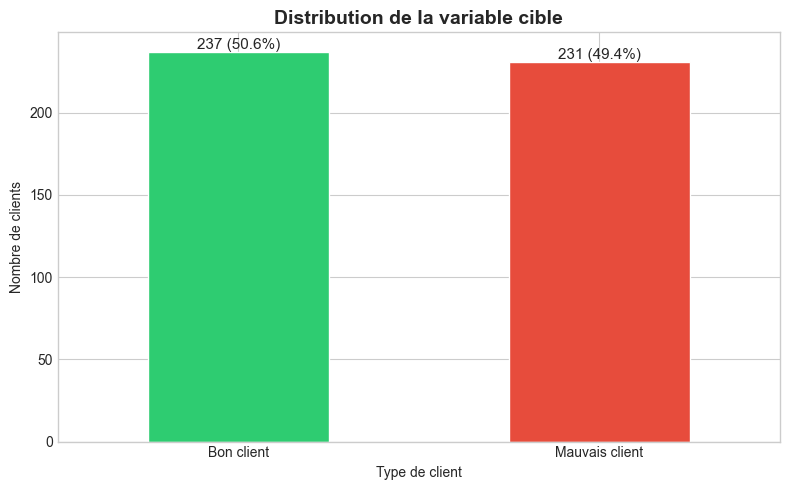

✅ Graphique sauvegardé


In [14]:
# =============================================================
# VISUALISATION — Distribution de la variable cible
# =============================================================

# Création du graphique en barres
fig, ax = plt.subplots(figsize=(8, 5))

# Couleurs : vert pour bon client, rouge pour mauvais client
colors = ['#2ecc71', '#e74c3c']
df['Type de client'].value_counts().plot(kind='bar', ax=ax, 
                                          color=colors, edgecolor='white')

# Titres et labels
ax.set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
ax.set_xlabel('Type de client')
ax.set_ylabel('Nombre de clients')
ax.tick_params(axis='x', rotation=0)

# Ajout des valeurs et pourcentages sur chaque barre
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
# Sauvegarde du graphique dans le dossier outputs/figures
plt.savefig('../outputs/figures/distribution_cible.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé")

### Exploration des variables catégorielles

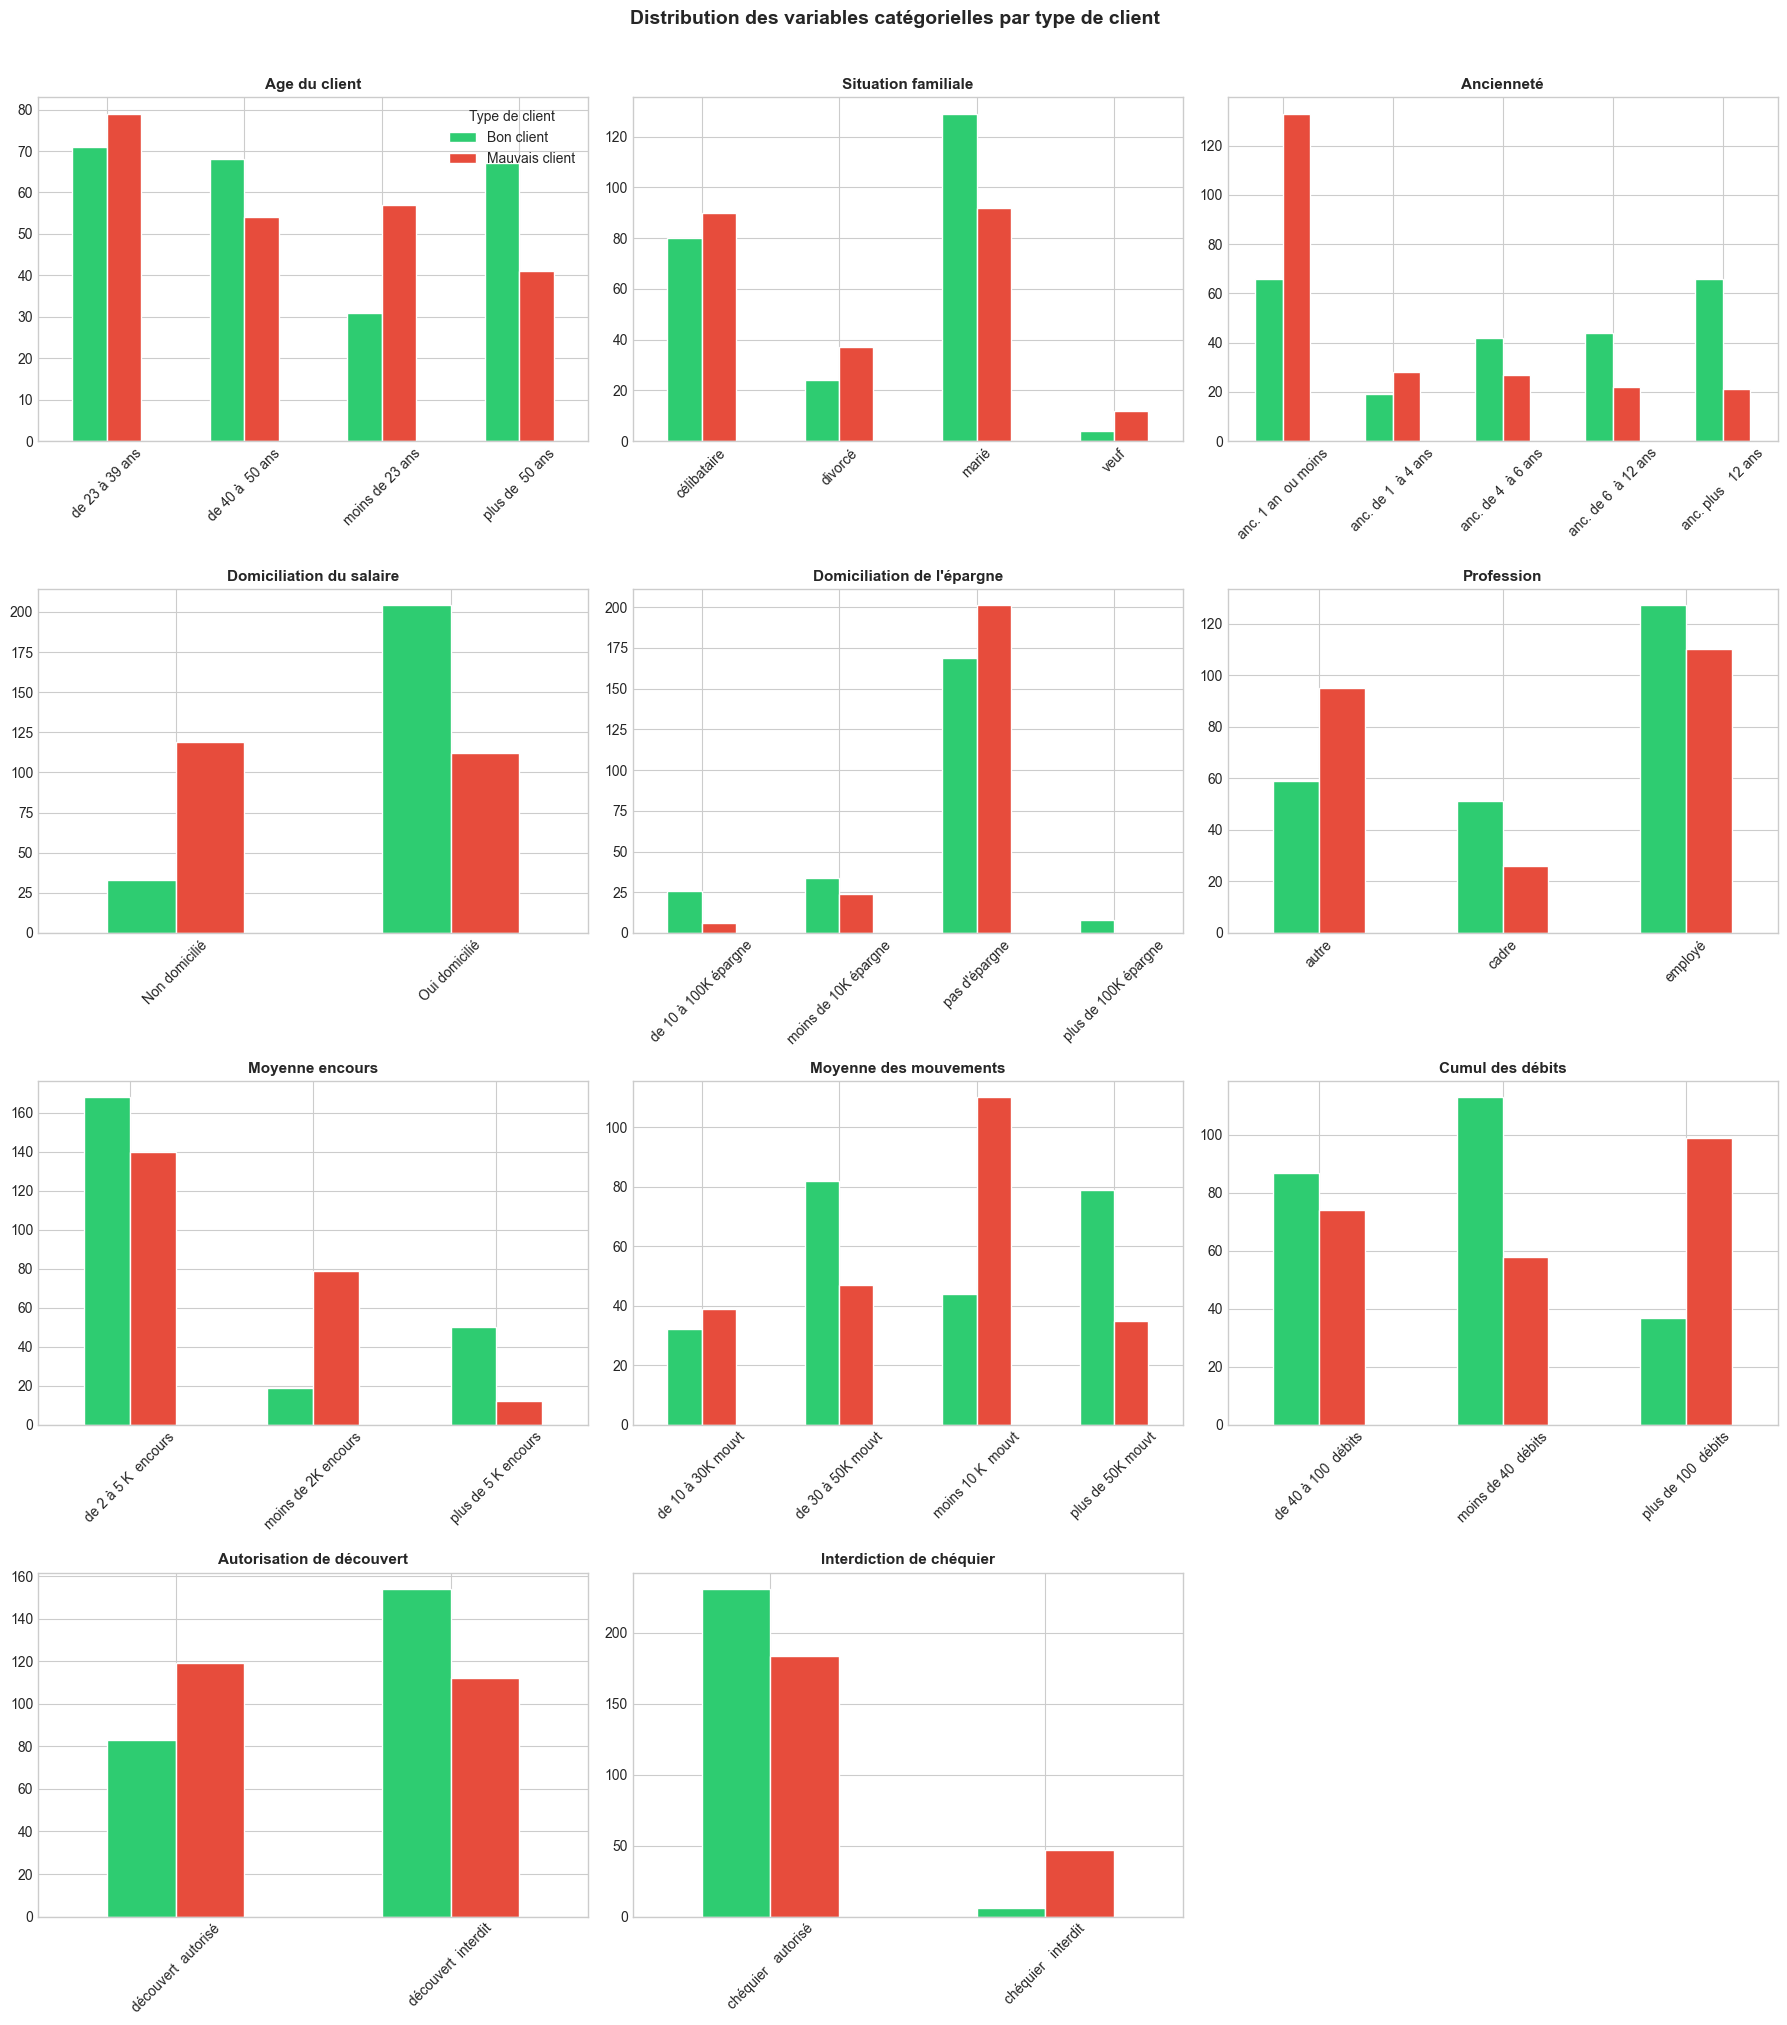

✅ Graphique sauvegardé


In [15]:
# =============================================================
# VISUALISATION — Variables catégorielles vs variable cible
# =============================================================

# Liste des variables catégorielles à analyser
cat_cols = ['Age du client', 'Situation familiale', 'Ancienneté',
            'Domiciliation du salaire', "Domiciliation de l'épargne",
            'Profession', 'Moyenne encours', 'Moyenne des mouvements',
            'Cumul des débits', 'Autorisation de découvert',
            'Interdiction de chéquier']

# Création d'une grille de sous-graphiques (4 lignes x 3 colonnes)
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()  # conversion en tableau 1D pour faciliter l'itération

for i, col in enumerate(cat_cols):
    # Comptage des clients par modalité et par type
    df_plot = df.groupby([col, 'Type de client']).size().unstack(fill_value=0)
    df_plot.plot(kind='bar', ax=axes[i], 
                 color=['#2ecc71', '#e74c3c'],
                 edgecolor='white', legend=(i==0))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Masquage de la dernière case vide
axes[-1].set_visible(False)

plt.suptitle('Distribution des variables catégorielles par type de client',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/variables_categorielles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")

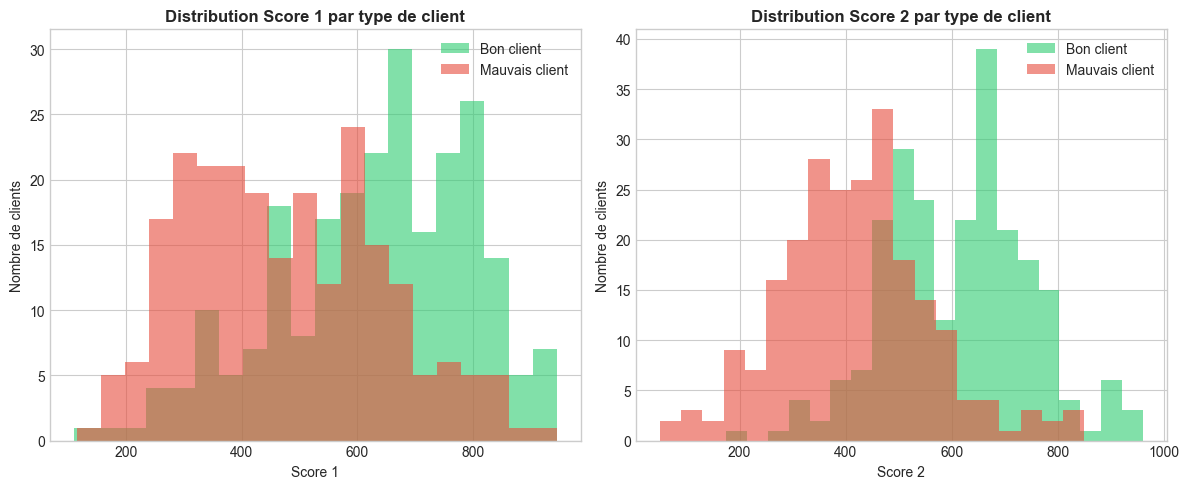

✅ Graphique sauvegardé


In [16]:
# =============================================================
# VISUALISATION — Variables numériques (Score 1 & Score 2)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['Score 1', 'Score 2']):
    # Histogramme superposé pour comparer les deux types de clients
    for client_type, color in zip(['Bon client', 'Mauvais client'], 
                                   ['#2ecc71', '#e74c3c']):
        df[df['Type de client'] == client_type][col].hist(
            ax=ax, alpha=0.6, label=client_type, color=color, bins=20)
    ax.set_title(f'Distribution {col} par type de client', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre de clients')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/variables_numeriques.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé")

### Observations clés de l'exploration

**Variables catégorielles :**
- **Domiciliation du salaire** : variable très discriminante — les bons clients domicilient majoritairement leur salaire
- **Ancienneté** : les bons clients ont une ancienneté plus longue (plus de 12 ans), les mauvais clients sont souvent récents (moins d'1 an)
- **Situation familiale** : les divorcés sont surreprésentés parmi les mauvais clients
- **Autorisation de découvert** : les mauvais clients ont plus souvent un découvert autorisé

**Variables numériques (Score 1 & Score 2) :**
- Les bons clients ont des scores élevés **(600-900)**
- Les mauvais clients ont des scores bas **(200-500)**
- Ces deux variables seront probablement les plus prédictives du modèle

**Dataset :**
- Parfaitement équilibré : 50.6% bons clients / 49.4% mauvais clients
- Aucune valeur manquante — pas de traitement nécessaire

## 2. Préparation des données

In [17]:
# =============================================================
# PRÉPARATION DES DONNÉES
# =============================================================

# Séparation des variables explicatives (X) et de la variable cible (y)
# X contient toutes les colonnes sauf "Type de client"
# y contient uniquement "Type de client" — c'est ce qu'on veut prédire
X = df.drop('Type de client', axis=1)
y = df['Type de client']

# Encodage de la variable cible en valeurs numériques
# "Bon client" → 0, "Mauvais client" → 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Encodage de la variable cible : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encodage des variables catégorielles en variables binaires (One-Hot Encoding)
# drop_first=True supprime la première modalité pour éviter la multicolinéarité
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"\nNombre de variables après encodage : {X_encoded.shape[1]}")
print(f"\n✅ Données encodées avec succès")

Encodage de la variable cible : {'Bon client': np.int64(0), 'Mauvais client': np.int64(1)}

Nombre de variables après encodage : 27

✅ Données encodées avec succès


In [18]:
# =============================================================
# DIVISION TRAIN / TEST (80% / 20%)
# =============================================================

# stratify=y_encoded garantit la même proportion de bons/mauvais clients
# dans les deux ensembles — essentiel pour un modèle non biaisé
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,       # 20% pour le test
    random_state=42,     # graine aléatoire pour la reproductibilité
    stratify=y_encoded
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} clients ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Ensemble de test        : {X_test.shape[0]} clients ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"\nRépartition train : Bon={sum(y_train==0)} | Mauvais={sum(y_train==1)}")
print(f"Répartition test  : Bon={sum(y_test==0)} | Mauvais={sum(y_test==1)}")
print(f"\n✅ Division stratifiée effectuée")

Ensemble d'entraînement : 374 clients (80%)
Ensemble de test        : 94 clients (20%)

Répartition train : Bon=189 | Mauvais=185
Répartition test  : Bon=48 | Mauvais=46

✅ Division stratifiée effectuée


In [20]:
# =============================================================
# STANDARDISATION DES VARIABLES NUMÉRIQUES
# =============================================================

# La standardisation centre les données (moyenne=0, écart-type=1)
# Nécessaire pour la régression logistique qui est sensible aux échelles
scaler = StandardScaler()

# Identification des colonnes numériques dans le dataset encodé
col_num = ['Score 1', 'Score 2']
col_num_encoded = [c for c in X_encoded.columns if c in col_num]

# Copie des données pour ne pas modifier les originaux
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# fit_transform sur le train — transform seulement sur le test
# IMPORTANT : on n'applique pas fit sur le test pour éviter le data leakage
X_train_scaled[col_num_encoded] = scaler.fit_transform(X_train[col_num_encoded])
X_test_scaled[col_num_encoded]  = scaler.transform(X_test[col_num_encoded])

print("✅ Standardisation effectuée")
print(f"   Variables standardisées : {col_num_encoded}")
print(f"   Moyenne Score 1 (train) : {X_train_scaled['Score 1'].mean():.4f}")
print(f"   Écart-type Score 1 (train) : {X_train_scaled['Score 1'].std():.4f}")

✅ Standardisation effectuée
   Variables standardisées : ['Score 1', 'Score 2']
   Moyenne Score 1 (train) : 0.0000
   Écart-type Score 1 (train) : 1.0013


## 3. Modélisation

Nous allons comparer deux modèles :
- **Régression Logistique** — modèle interprétable, idéal pour comprendre l'impact de chaque variable
- **Random Forest** — modèle plus puissant, capte les relations non-linéaires

Pour chaque modèle on évaluera :
- L'accuracy
- Le F1-score
- La courbe ROC et l'AUC
- La matrice de confusion

In [21]:
# =============================================================
# MODÈLE 1 — Régression Logistique
# =============================================================

# Création et entraînement du modèle
# max_iter=1000 pour assurer la convergence
# random_state=42 pour la reproductibilité
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Prédictions sur le jeu de test
y_pred_lr = lr_model.predict(X_test_scaled)

# Probabilités de prédiction (nécessaires pour la courbe ROC)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== RÉGRESSION LOGISTIQUE ===")
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_lr, 
                            target_names=['Bon client', 'Mauvais client']))

=== RÉGRESSION LOGISTIQUE ===

Accuracy : 0.7979

Rapport de classification :
                precision    recall  f1-score   support

    Bon client       0.76      0.88      0.82        48
Mauvais client       0.85      0.72      0.78        46

      accuracy                           0.80        94
     macro avg       0.80      0.80      0.80        94
  weighted avg       0.80      0.80      0.80        94



In [22]:
# =============================================================
# MODÈLE 2 — Random Forest
# =============================================================

# n_estimators=100 : nombre d'arbres de décision
# random_state=42 pour la reproductibilité
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Prédictions sur le jeu de test
y_pred_rf = rf_model.predict(X_test_scaled)

# Probabilités de prédiction
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== RANDOM FOREST ===")
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Bon client', 'Mauvais client']))

=== RANDOM FOREST ===

Accuracy : 0.7872

Rapport de classification :
                precision    recall  f1-score   support

    Bon client       0.77      0.83      0.80        48
Mauvais client       0.81      0.74      0.77        46

      accuracy                           0.79        94
     macro avg       0.79      0.79      0.79        94
  weighted avg       0.79      0.79      0.79        94



### Résultats comparatifs des modèles

| Modèle | Accuracy | F1 Bon client | F1 Mauvais client |
|--------|----------|---------------|-------------------|
| Régression Logistique | **79.8%** | **0.82** | **0.78** |
| Random Forest | 78.7% | 0.80 | 0.77 |

**Observation :** La régression logistique performe légèrement mieux que le Random Forest. 
Ce résultat est cohérent avec un dataset de taille modeste (468 clients) — 
la régression logistique est souvent plus efficace sur les petits datasets 
car elle est moins sujette au surapprentissage (overfitting).

## 4. Évaluation et comparaison des modèles

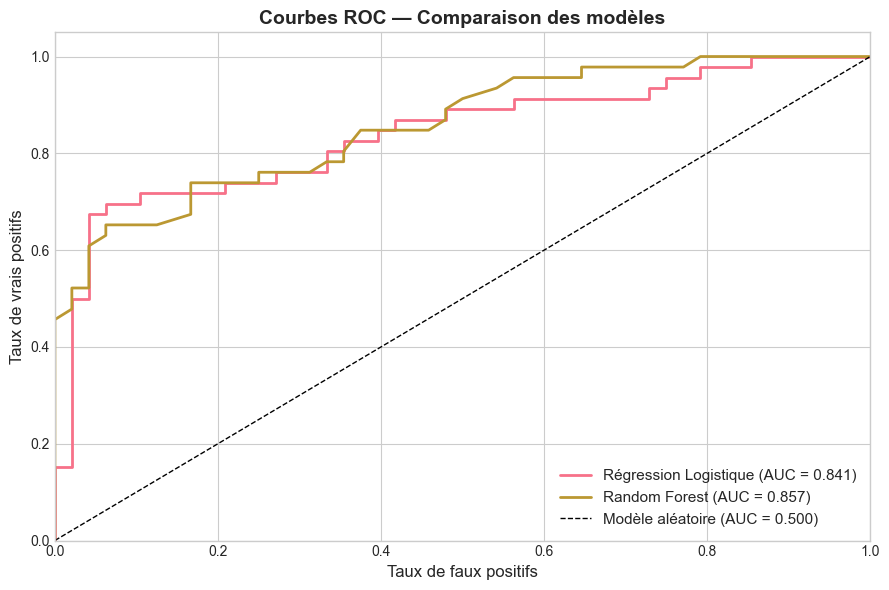

✅ Courbes ROC sauvegardées


In [23]:
# =============================================================
# COURBES ROC — Comparaison des deux modèles
# =============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# Calcul des courbes ROC pour chaque modèle
for model_name, y_prob in [('Régression Logistique', y_prob_lr), 
                             ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, 
            label=f'{model_name} (AUC = {roc_auc:.3f})')

# Ligne de référence (modèle aléatoire)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modèle aléatoire (AUC = 0.500)')

ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../outputs/figures/courbes_roc.png', dpi=150)
plt.show()
print("✅ Courbes ROC sauvegardées")

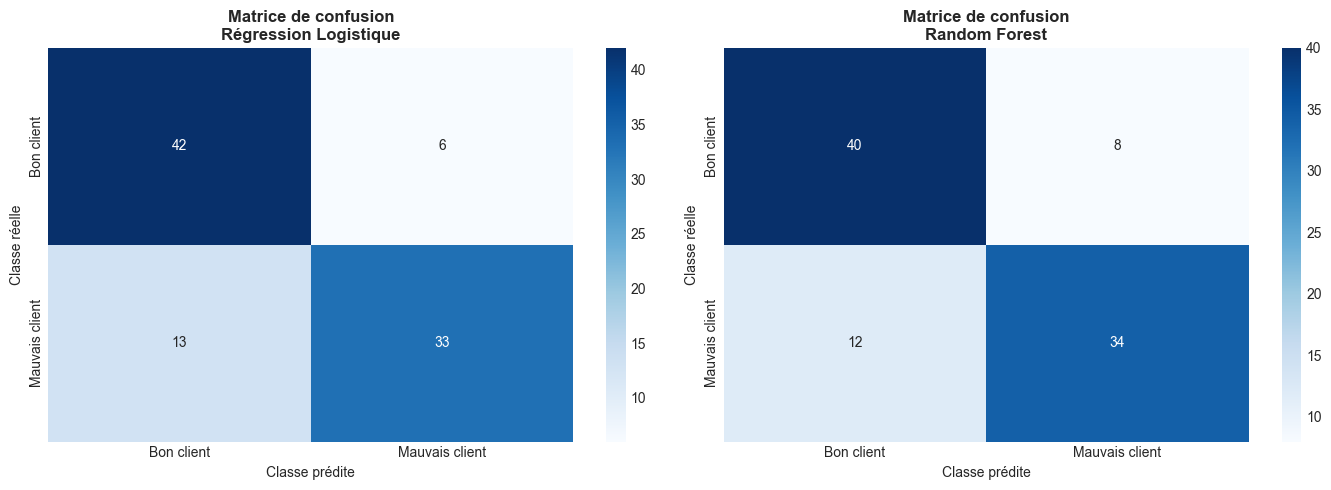

✅ Matrices de confusion sauvegardées


In [24]:
# =============================================================
# MATRICES DE CONFUSION — Comparaison des deux modèles
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name, y_pred in [
    (axes[0], 'Régression Logistique', y_pred_lr),
    (axes[1], 'Random Forest', y_pred_rf)
]:
    # Calcul de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    
    # Affichage avec heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Mauvais client'],
                yticklabels=['Bon client', 'Mauvais client'])
    ax.set_title(f'Matrice de confusion\n{model_name}', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')

plt.tight_layout()
plt.savefig('../outputs/figures/matrices_confusion.png', dpi=150)
plt.show()
print("✅ Matrices de confusion sauvegardées")

In [25]:
# =============================================================
# VALIDATION CROISÉE — Vérification de la robustesse
# =============================================================

# La validation croisée divise le dataset en 5 parties
# et entraîne/teste le modèle 5 fois — donne une mesure plus fiable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in [('Régression Logistique', lr_model), 
                            ('Random Forest', rf_model)]:
    scores = cross_val_score(model, X_encoded, y_encoded, 
                             cv=cv, scoring='accuracy')
    print(f"{model_name} :")
    print(f"  Accuracy par fold : {[f'{s:.3f}' for s in scores]}")
    print(f"  Moyenne : {scores.mean():.3f} (+/- {scores.std():.3f})")
    print()

Régression Logistique :
  Accuracy par fold : ['0.809', '0.755', '0.755', '0.753', '0.806']
  Moyenne : 0.776 (+/- 0.026)

Random Forest :
  Accuracy par fold : ['0.840', '0.787', '0.755', '0.763', '0.796']
  Moyenne : 0.788 (+/- 0.030)



### Analyse des résultats d'évaluation

#### Courbes ROC
- Régression Logistique : AUC = **0.841**
- Random Forest : AUC = **0.857**
- Les deux modèles sont bien au-dessus du modèle aléatoire (AUC = 0.500)
- Le Random Forest a un meilleur AUC mais une accuracy légèrement inférieure

#### Matrices de confusion
**Régression Logistique :**
- 42 bons clients correctement identifiés (vrais positifs)
- 33 mauvais clients correctement identifiés (vrais négatifs)
- 6 bons clients mal classés comme mauvais (faux négatifs)
- 13 mauvais clients mal classés comme bons (faux positifs) ⚠️

**Random Forest :**
- 40 bons clients correctement identifiés
- 34 mauvais clients correctement identifiés
- 8 bons clients mal classés
- 12 mauvais clients mal classés comme bons ⚠️

#### Validation croisée (5 folds)
- Régression Logistique : moyenne **77.6%** (+/- 2.6%) — stable
- Random Forest : moyenne **78.8%** (+/- 3.0%) — légèrement meilleur mais plus variable

#### Conclusion sur les modèles
En contexte bancaire, les **faux positifs** (mauvais clients classés comme bons) 
sont les erreurs les plus coûteuses car elles génèrent des impayés.
La régression logistique détecte légèrement mieux les mauvais clients (13 vs 12) 
mais reste très proche du Random Forest.

**Modèle retenu : Régression Logistique** — meilleure interprétabilité 
et performances comparables, ce qui est crucial pour justifier les décisions 
de crédit aux régulateurs bancaires.

## 5. Interprétation — Variables les plus importantes

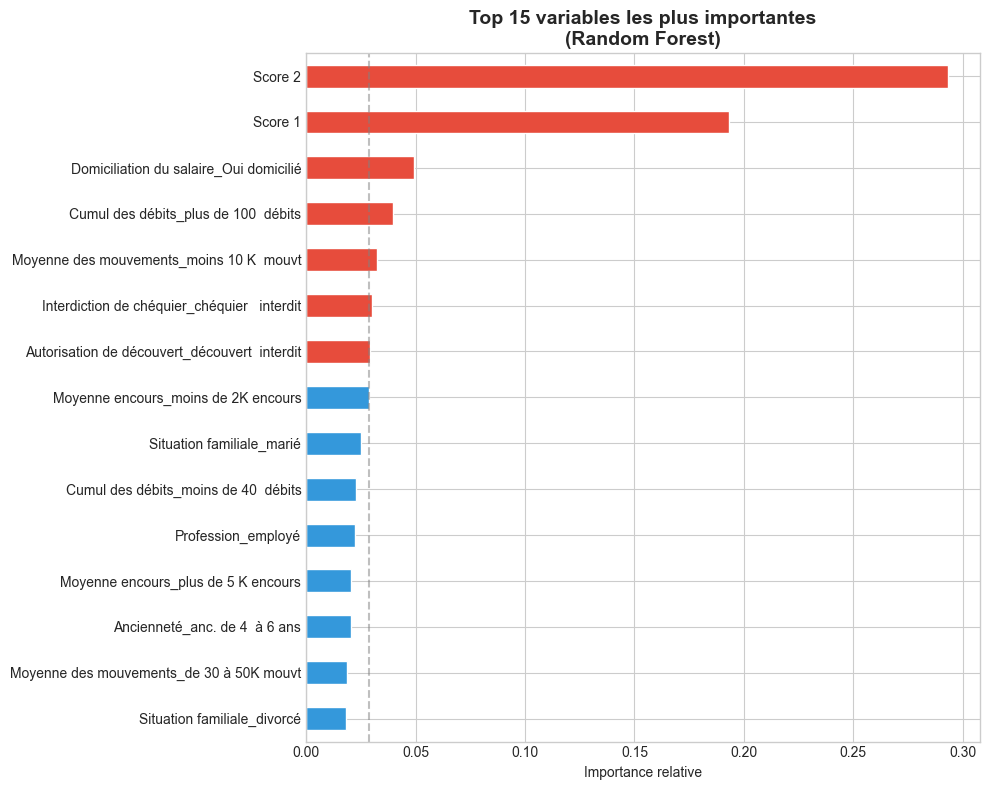

✅ Graphique sauvegardé


In [26]:
# =============================================================
# IMPORTANCE DES VARIABLES — Random Forest
# =============================================================

# Le Random Forest calcule l'importance de chaque variable
# basée sur la réduction d'impureté à chaque nœud de décision
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=True).tail(15)  # Top 15 variables

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > importances.median() else '#3498db' 
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 15 variables les plus importantes\n(Random Forest)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance relative')
ax.axvline(x=importances.median(), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/figures/importance_variables.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé")

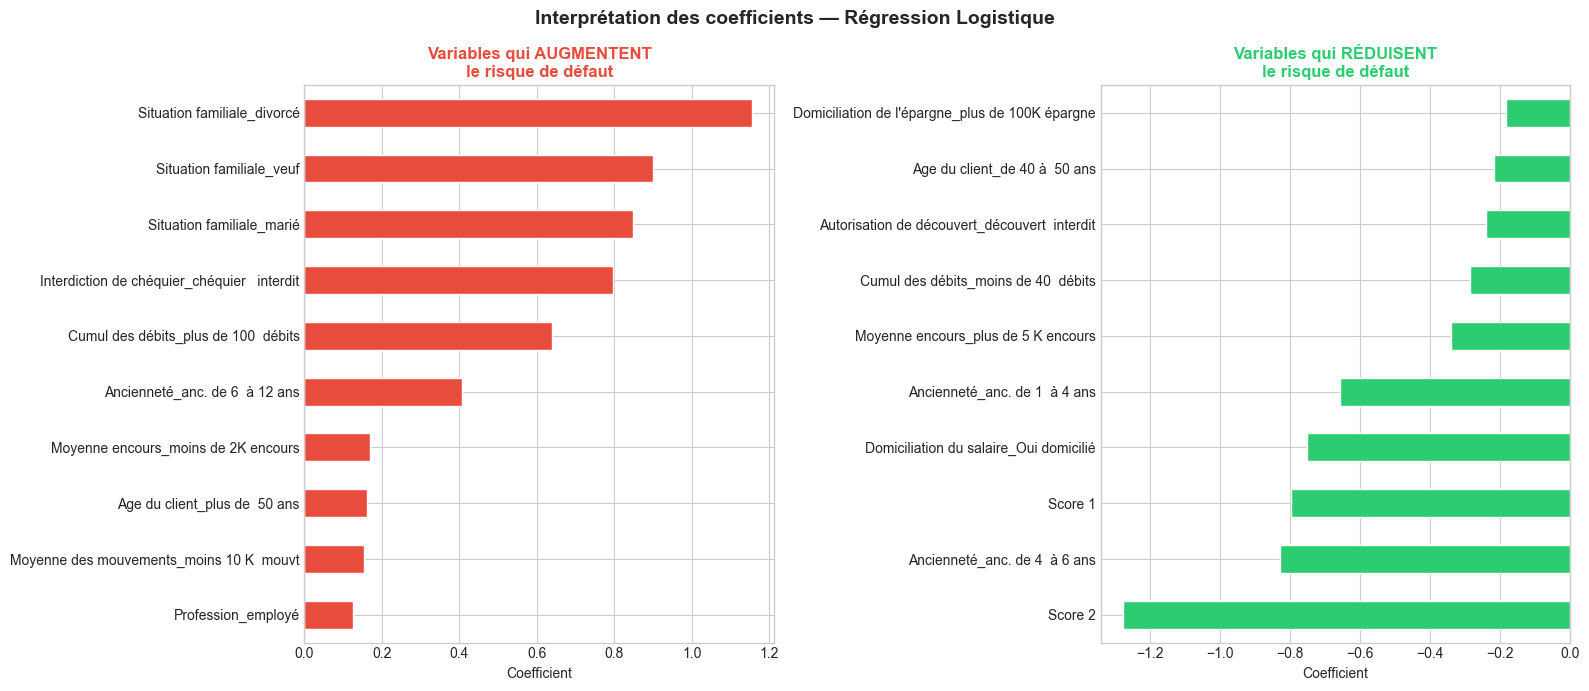

✅ Graphique sauvegardé


In [27]:
# =============================================================
# COEFFICIENTS — Régression Logistique
# =============================================================

# Les coefficients montrent l'impact de chaque variable sur la probabilité
# d'être un mauvais client — positif = augmente le risque
coefficients = pd.Series(
    lr_model.coef_[0],
    index=X_encoded.columns
).sort_values(ascending=True)

# Top 10 variables qui AUGMENTENT le risque
top_risque = coefficients.tail(10)
# Top 10 variables qui RÉDUISENT le risque  
top_protecteur = coefficients.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Variables qui augmentent le risque
top_risque.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Variables qui AUGMENTENT\nle risque de défaut', 
                   fontsize=12, fontweight='bold', color='#e74c3c')
axes[0].set_xlabel('Coefficient')

# Variables protectrices
top_protecteur.plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Variables qui RÉDUISENT\nle risque de défaut',
                   fontsize=12, fontweight='bold', color='#2ecc71')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Interprétation des coefficients — Régression Logistique',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/coefficients_lr.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé")

### Interprétation des variables — Insights métier

#### Variables qui AUGMENTENT le risque de défaut
- **Situation familiale divorcé/veuf** : les personnes en rupture familiale 
  présentent un risque plus élevé — instabilité financière potentielle
- **Interdiction de chéquier** : signal fort d'incidents bancaires passés
- **Cumul des débits élevé** (plus de 100 débits) : comportement de dépense excessif
- **Ancienneté 6 à 12 ans** : paradoxalement plus risqué que les très anciens clients

#### Variables qui RÉDUISENT le risque de défaut
- **Score 2 et Score 1** : les scores internes sont les meilleurs prédicteurs — 
  confirme leur pertinence pour l'octroi de crédit
- **Ancienneté 4 à 6 ans** : les clients fidèles sont moins risqués
- **Domiciliation du salaire** : signe de confiance et d'engagement bancaire
- **Encours élevé** (plus de 5K) : les clients avec plus d'épargne sont moins risqués

#### Confirmation par le Random Forest
Le Random Forest confirme que **Score 2 et Score 1** sont de loin 
les variables les plus prédictives, suivies de la domiciliation du salaire 
et du cumul des débits.

#### Recommandations métier
1. Prioriser les **scores internes** dans la décision d'octroi
2. Vérifier systématiquement l'**historique de chéquier**
3. La **domiciliation du salaire** doit être un critère favorisant l'octroi
4. Être vigilant sur les clients avec un **cumul de débits très élevé**

## 6. Conclusion générale

### Résultats du projet
| Métrique | Régression Logistique | Random Forest |
|----------|----------------------|---------------|
| Accuracy | 79.8% | 78.7% |
| AUC-ROC | 0.841 | 0.857 |
| F1 Bon client | 0.82 | 0.80 |
| F1 Mauvais client | 0.78 | 0.77 |
| CV Accuracy (5 folds) | 77.6% (+/-2.6%) | 78.8% (+/-3.0%) |

### Modèle recommandé
La **Régression Logistique** est retenue comme modèle final pour trois raisons :
1. **Performances équivalentes** au Random Forest sur ce dataset
2. **Interprétabilité** des coefficients — essentielle pour justifier 
   les décisions de crédit aux régulateurs (Bâle III, RGPD)
3. **Stabilité** — écart-type plus faible en validation croisée

### Limites et perspectives
- Dataset relativement petit (468 clients) — à enrichir avec plus de données
- Tester d'autres algorithmes : XGBoost, SVM
- Intégrer des données comportementales (historique de transactions)
- Déployer le modèle via une API pour une utilisation en temps réel

In [28]:
# =============================================================
# SAUVEGARDE DU MODÈLE FINAL
# =============================================================
import pickle
import os

# Création du dossier models si nécessaire
os.makedirs('../outputs/models', exist_ok=True)

# Sauvegarde du modèle, du scaler et de l'encodeur
with open('../outputs/models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../outputs/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Modèle sauvegardé dans outputs/models/")
print("   - logistic_regression_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("\n🎉 Notebook terminé avec succès !")

✅ Modèle sauvegardé dans outputs/models/
   - logistic_regression_model.pkl
   - scaler.pkl
   - label_encoder.pkl

🎉 Notebook terminé avec succès !
